In [2]:
import train
%load_ext autoreload
%autoreload 2
import tools
from analysis import performance
from analysis import standard_analysis
from analysis import clustering
from analysis import variance
from analysis import taskset
from analysis import varyhp
from analysis import data_analysis
from analysis import contextdm_analysis
from analysis import posttrain_analysis
from network import Model
import tensorflow as tf
import numpy as np

/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/fbraidi/miniconda3/env

In [ ]:
model_dir='./../models/fdgo_fdanti_delaygo_256'
replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

compositional_rules={'go':[-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                     'dm1':[0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
                     'dm2':[0,0,0,1,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
                     'contextdm1':[0,0,0,1,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0],
                     'contextdm2':[0,0,0,1,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0],
                     'multidm':[0,0,0,1,0,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0]}

pure_tasks_perfs=[]
comp_tasks_perf=[]

for i in range(len(replace_rule)):

    rule_strength=[0]*len(replace_rule)
    rule_strength[i]=1
    perf, _ = taskset.run_network_replacerule(model_dir, replace_rule[i], replace_rule, rule_strength)
    pure_tasks_perfs.append(perf)

for el in compositional_rules:

    perf, _ = taskset.run_network_replacerule(model_dir, 'delayanti', replace_rule, compositional_rules[el])
    comp_tasks_perf.append((el,perf))

for i in range(len(replace_rule)):

    print(f'Performance on task {replace_rule[i]}: ', pure_tasks_perfs[i])

for (fam,perf) in comp_tasks_perf:

    print(f'Performance on delayanti when instructed with {fam} family: ', perf)

INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_256/model.ckpt


Model restored from file: ./../models/fdgo_fdanti_delaygo_256/model.ckpt
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_256/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_256/model.ckpt
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_256/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_256/model.ckpt
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_256/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_256/model.ckpt
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_256/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_256/model.ckpt
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_256/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_256/model.ckpt
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_256/model.ckpt
Model restored from file: ./

In [ ]:
model_dir='prova2'
replace_rule=np.array(['delayanti', 'fdanti', 'delaygo', 'fdgo', 'delaydm1', 'dm1'])

perf, _ = taskset.run_network_replacerule(model_dir, 'fdanti', replace_rule, [0,1,0,0,0,0])
print('fdanti performance: ',perf)
perf, _ = taskset.run_network_replacerule(model_dir, 'delaygo', replace_rule, [0,0,1,0,0,0])
print('delaygo performance: ',perf)
perf, _ = taskset.run_network_replacerule(model_dir, 'fdgo', replace_rule, [0,0,0,1,0,0])
print('fdgo performance: ',perf)
perf, _ = taskset.run_network_replacerule(model_dir, 'delayanti', replace_rule, [1,0,0,0,0,0])
print('fdgo performance: ',perf)
perf, _ = taskset.run_network_replacerule(model_dir, 'delaydm1', replace_rule, [0,0,0,0,1,0])
print('delaydm1 performance: ',perf)
perf, _ = taskset.run_network_replacerule(model_dir, 'dm1', replace_rule, [0,0,0,0,0,1])
print('dm1 performance: ',perf)
perf, _ = taskset.run_network_replacerule(model_dir, 'delayanti', replace_rule, [0,1,1,-1,0,0])
print('delayanti performance from go: ',perf)
perf, _ = taskset.run_network_replacerule(model_dir, 'delayanti', replace_rule, [0,1,0,0,1,-1])
print('delayanti performance from dm1: ',perf)

INFO:tensorflow:Restoring parameters from prova2/model.ckpt
Model restored from file: prova2/model.ckpt
fdanti performance:  0.038
INFO:tensorflow:Restoring parameters from prova2/model.ckpt
Model restored from file: prova2/model.ckpt
delaygo performance:  0.604
INFO:tensorflow:Restoring parameters from prova2/model.ckpt
Model restored from file: prova2/model.ckpt
fdgo performance:  0.869
INFO:tensorflow:Restoring parameters from prova2/model.ckpt
Model restored from file: prova2/model.ckpt
delaydm1 performance:  0.6210000000000001
INFO:tensorflow:Restoring parameters from prova2/model.ckpt
Model restored from file: prova2/model.ckpt
dm1 performance:  0.64
INFO:tensorflow:Restoring parameters from prova2/model.ckpt
Model restored from file: prova2/model.ckpt
delayanti performance from go:  0.09699999999999999
INFO:tensorflow:Restoring parameters from prova2/model.ckpt
Model restored from file: prova2/model.ckpt
delayanti performance from dm1:  0.14999999999999997


In [34]:
train.train(model_dir='compositional_delayanti', 
                hp={'learning_rate': 0.001, 
                    'n_rnn': 1024,
                    'w_rec_init': 'randgauss',
                    'b_rec_init': 'uniform',
                    'rule_strength': 0.,
                    'no_rule': False,
                    'target_perf': 0.90,
                    'activation': 'softplus',
                    'alpha': 0.2,
                    'use_separate_input':True,
                    'train_rule_bias':True,
                    'rule_input_bias_init':{'fdanti':1,
                                            'fdgo':-1,
                                            'delaygo':1}},
                ruleset='all',
                rule_trains=['delayanti'], # Current rule to train
                pretrained_dir='fdgo_fdanti_delaygo',
                apply_pretrained_params='all',
                trainables='rule_bias')

TypeError: 'NoneType' object is not subscriptable

Overwrite original dt with 1.0
INFO:tensorflow:Restoring parameters from fdgo_fdanti_delaygo/model.ckpt
Model restored from file: fdgo_fdanti_delaygo/model.ckpt


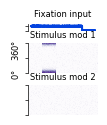

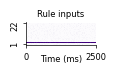

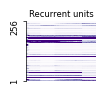

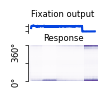

In [6]:
standard_analysis.schematic_plot(model_dir='fdgo_fdanti_delaygo', rule='delaygo')

Overwrite original dt with 1.0
INFO:tensorflow:Restoring parameters from compositional_delayanti/model.ckpt


Model restored from file: compositional_delayanti/model.ckpt


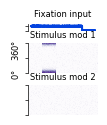

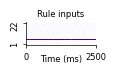

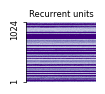

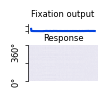

In [19]:
standard_analysis.schematic_plot(model_dir='compositional_delayanti', rule='delayanti')

Overwrite original dt with 1.0
INFO:tensorflow:Restoring parameters from compositional_delayanti/model.ckpt
Model restored from file: compositional_delayanti/model.ckpt


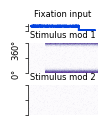

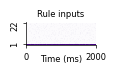

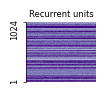

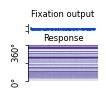

In [20]:
standard_analysis.schematic_plot(model_dir='compositional_delayanti', rule='fdgo')